## End-to-End Recommendation System

This notebook will guide you through the process of building a collaborative filtering recommendation system using the `Reviews.csv` dataset. We will cover:

1.  **Data Loading and Initial Inspection**
2.  **Exploratory Data Analysis (EDA)**
3.  **Data Preprocessing and Cleaning**
4.  **Building a Matrix Factorization Model (SVD)**
5.  **Model Evaluation and Comparison (Cross-Validation)**
6.  **Generating Recommendations**
7.  **Model Deployment (Saving and Loading)**

### Step 1: Data Loading and Initial Inspection

First, we'll load the dataset into a pandas DataFrame. Given previous parsing issues, we'll use `engine='python'` and `on_bad_lines='skip'` to handle potential errors, loading the first 100,000 rows to get a substantial sample for our recommendation system. We'll then perform an initial inspection of the data.

In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Harsh Tiwari\\OneDrive\\Desktop\\Projects\\Product Recommendation System\\data\\Reviews.csv", engine='python', on_bad_lines='skip')
display(df.head())

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### Step 2: Exploratory Data Analysis (EDA)

Now that we have loaded the data, let's perform some Exploratory Data Analysis to understand its structure, distributions, and identify any potential issues or patterns. This will include:

*   Checking for missing values.
*   Understanding the distribution of ratings (`Score`).
*   Analyzing `HelpfulnessRatio`.
*   Identifying top users and products.
*   Converting and analyzing the `Time` column.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nDescriptive statistics for numerical columns:")
display(df.describe())

print("\nDescriptive statistics for object (categorical/text) columns:")
display(df.describe(include='object'))


Missing values per column:


Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


Descriptive statistics for numerical columns:


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09



Descriptive statistics for object (categorical/text) columns:


,ProductId,UserId,ProfileName,Summary,Text
count,568454,568454,568428,568427,568454
unique,74258,256059,218415,295742,393579
top,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",Delicious!,"This review will make me sound really stupid, ..."
freq,913,448,451,2462,199


C:\Users\Harsh Tiwari\AppData\Local\Temp\ipykernel_11828\2190098818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


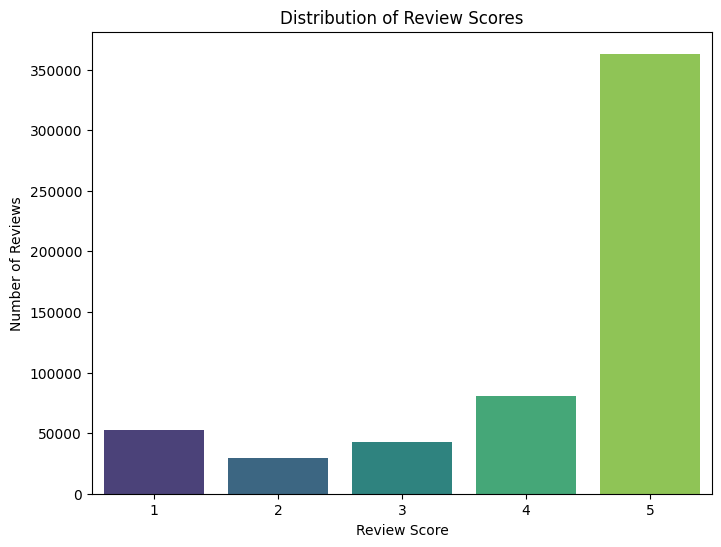

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

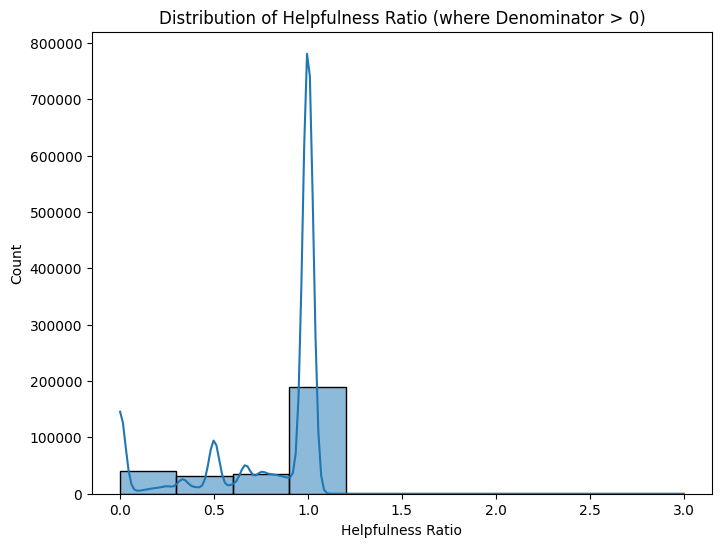

In [4]:
# Calculate Helpfulness Ratio, handling division by zero
df['HelpfulnessRatio'] = df.apply(lambda row: row['HelpfulnessNumerator'] / row['HelpfulnessDenominator'] if row['HelpfulnessDenominator'] != 0 else 0, axis=1)

plt.figure(figsize=(8, 6))
sns.histplot(df[df['HelpfulnessDenominator'] > 0]['HelpfulnessRatio'], bins=10, kde=True)
plt.title('Distribution of Helpfulness Ratio (where Denominator > 0)')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Count')
plt.show()


In [5]:
print("\nTop 10 Products by number of reviews:")
product_counts = df['ProductId'].value_counts()
display(product_counts.head(10))

print("\nTop 10 Users by number of reviews:")
user_counts = df['UserId'].value_counts()
display(user_counts.head(10))



Top 10 Products by number of reviews:


ProductId
B007JFMH8M    913
B0026RQTGE    632
B002QWHJOU    632
B002QWP89S    632
B002QWP8H0    632
B003B3OOPA    623
B001EO5Q64    567
B000VK8AVK    564
B0026KNQSA    564
B007M83302    564
Name: count, dtype: int64


Top 10 Users by number of reviews:


UserId
A3OXHLG6DIBRW8    448
A1YUL9PCJR3JTY    421
AY12DBB0U420B     389
A281NPSIMI1C2R    365
A1Z54EM24Y40LL    256
A1TMAVN4CEM8U8    204
A2MUGFV2TDQ47K    201
A3TVZM3ZIXG8YW    199
A3PJZ8TU8FDQ1K    178
AQQLWCMRNDFGI     176
Name: count, dtype: int64

DataFrame after converting 'Time' column:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,HelpfulnessRatio
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0.0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,1.0
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,1.0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,0.0


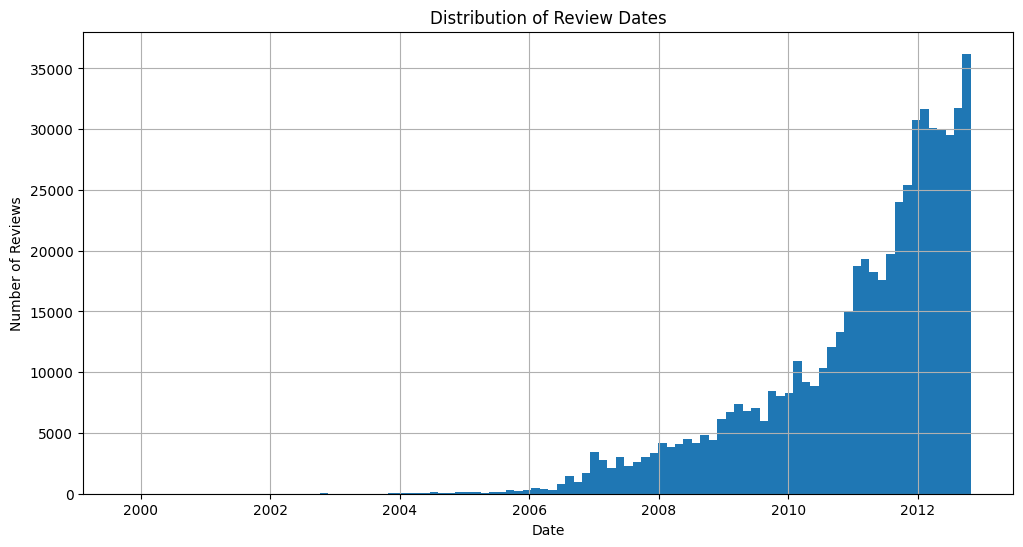

In [6]:
df['Time'] = pd.to_datetime(df['Time'], unit='s')

# Print a message indicating the conversion.
print("DataFrame after converting 'Time' column:")
# Display the first few rows of the DataFrame to show the updated 'Time' column.
display(df.head())

# Create a new figure for the histogram of review dates.
plt.figure(figsize=(12, 6))
# Generate a histogram of the 'Time' column.
# '.hist(bins=100)' creates a histogram with 100 bins, showing the distribution of review dates.
df['Time'].hist(bins=100)

plt.title('Distribution of Review Dates')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

### Step 3: Data Preprocessing and Cleaning

For a collaborative filtering recommendation system, the key columns are `UserId`, `ProductId`, and `Score`. Other columns like `ProfileName`, `Summary`, `Text`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Time`, and `Id` are not directly used by the SVD model. We will filter the dataset to include only users and products with a sufficient number of ratings to ensure model quality and efficiency.

We will define minimum thresholds for user and product ratings.

In [7]:
# Define the minimum number of ratings required for a user and a product to be included in the dataset.
min_user_ratings = 5
min_item_ratings = 5

# Filter out users who have made fewer than 'min_user_ratings'.
# First, count how many ratings each user has.
user_counts = df['UserId'].value_counts()
df_filtered_users = df[df['UserId'].isin(user_counts[user_counts >= min_user_ratings].index)]

# Filter out products that have fewer than 'min_item_ratings'.
product_counts = df_filtered_users['ProductId'].value_counts()
df_filtered = df_filtered_users[df_filtered_users['ProductId'].isin(product_counts[product_counts >= min_item_ratings].index)]

# Print the number of reviews at each stage of filtering to show the reduction in data size.
print(f"Original number of reviews: {len(df)}")
print(f"Number of reviews after filtering users with < {min_user_ratings} ratings: {len(df_filtered_users)}")
print(f"Number of reviews after filtering products with < {min_item_ratings} ratings: {len(df_filtered)}")

display(df_filtered.head())

# Check and print the number of unique users and products remaining after filtering.
print(f"Unique users after filtering: {df_filtered['UserId'].nunique()}")
print(f"Unique products after filtering: {df_filtered['ProductId'].nunique()}")


Original number of reviews: 568454
Number of reviews after filtering users with < 5 ratings: 243907
Number of reviews after filtering products with < 5 ratings: 195807


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,HelpfulnessRatio
32,33,B001EO5QW8,AOVROBZ8BNTP7,S. Potter,19,19,4,2006-11-13,Best of the Instant Oatmeals,McCann's Instant Oatmeal is great if you must ...,1.0
39,40,B001EO5QW8,AO80AC8313NIZ,kYpondman,0,0,5,2011-09-28,Wife's favorite Breakfast,I ordered this for my wife as it was reccomend...,0.0
40,41,B001EO5QW8,AQCY5KRO7489S,Garrett,0,0,5,2011-04-22,Why wouldn't you buy oatmeal from Mcanns? Tast...,The variety packs taste great!<br /><br />I ha...,0.0
43,44,B001EO5QW8,A17DW6SUOC70DJ,Mother of 9,0,0,5,2009-10-13,Good Hot Breakfast,McCann's Oatmeal is a good quality choice. Ou...,0.0
44,45,B001EO5QW8,A2G7B7FKP2O2PU,D. Leschke,0,0,5,2008-05-02,Great taste and convenience,We really like the McCann's steel cut oats but...,0.0


Unique users after filtering: 22692
Unique products after filtering: 6544


In [ ]:
!pip install scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-win_amd64.whl size=1321551 sha256=068faa64008f61253396ef37527c2a769784d1ef63666fae740b6d89a4135dab
  Stored in directory: c:\users\harsh tiwari\appdata\local\pip\cache\wheels\2a\8f\6e\7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Step 4: Building a Matrix Factorization Model (SVD)

We will use the `surprise` library to implement a Singular Value Decomposition (SVD) model, which is a powerful matrix factorization technique for collaborative filtering. This involves:

1.  **Loading data into `surprise`'s format.**
2.  **Splitting data into training and test sets.**
3.  **Training the SVD algorithm.**

In [8]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split

# A Reader is needed to parse the dataset. The rating_scale parameter specifies
# the range of ratings. Our scores are from 1 to 5.
reader = Reader(rating_scale=(1, 5))

# We only need 'UserId', 'ProductId', and 'Score' columns.
data = Dataset.load_from_df(df_filtered[['UserId', 'ProductId', 'Score']], reader)

print("Data loaded into surprise Dataset format.")

# Split data into training and testing sets (80% train, 20% test)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Number of ratings in training set: {len(list(trainset.all_ratings()))}")
print(f"Number of ratings in test set: {len(testset)}")

# Initialize the SVD algorithm
# Parameters like n_epochs, n_factors, lr_all, reg_all can be tuned for better performance
algo = SVD(random_state=42, n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)

# Train the algorithm on the training set
print("\nTraining SVD model...")
algo.fit(trainset)

print("SVD model trained successfully.")

Data loaded into surprise Dataset format.
Number of ratings in training set: 156645
Number of ratings in test set: 39162

Training SVD model...
SVD model trained successfully.


### Step 5: Model Evaluation and Comparison (Cross-Validation)

Evaluating the model's performance is crucial. We'll use metrics like Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) on the test set. To get a more robust evaluation, we'll also perform k-fold cross-validation and compare SVD with a simpler baseline model like `NormalPredictor`.

In [9]:
from surprise import accuracy
from surprise.model_selection import cross_validate
from surprise import NormalPredictor

# Make predictions on the test set
predictions = algo.test(testset)

# Calculate and print RMSE and MAE on the test set
print("\n--- Model Evaluation on Test Set ---")
accuracy.rmse(predictions, verbose=True)
accuracy.mae(predictions, verbose=True)

print("\n--- Cross-Validation for SVD ---")
# Perform 5-fold cross-validation for SVD
cv_results_svd = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=-1)
print(f"Average SVD RMSE (CV): {cv_results_svd['test_rmse'].mean():.4f}")
print(f"Average SVD MAE (CV): {cv_results_svd['test_mae'].mean():.4f}")

print("\n--- Cross-Validation for NormalPredictor (Baseline) ---")
# Compare with a baseline model (e.g., predicting the global average rating)
baseline_algo = NormalPredictor()
cv_results_baseline = cross_validate(baseline_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=-1)
print(f"Average Baseline RMSE (CV): {cv_results_baseline['test_rmse'].mean():.4f}")
print(f"Average Baseline MAE (CV): {cv_results_baseline['test_mae'].mean():.4f}")

print("\nComparison shows that SVD generally performs better (lower RMSE/MAE) than the simple NormalPredictor baseline, indicating it's learning user-item preferences.")


--- Model Evaluation on Test Set ---
RMSE: 0.7919
MAE:  0.5455

--- Cross-Validation for SVD ---
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.7831  0.7846  0.7791  0.7929  0.7879  0.7855  0.0047  
MAE (testset)     0.5377  0.5401  0.5377  0.5454  0.5435  0.5409  0.0031  
Fit time          0.82    1.05    1.04    0.92    0.80    0.92    0.10    
Test time         0.50    0.38    0.29    0.30    0.25    0.34    0.09    
Average SVD RMSE (CV): 0.7855
Average SVD MAE (CV): 0.5409

--- Cross-Validation for NormalPredictor (Baseline) ---
Evaluating RMSE, MAE of algorithm NormalPredictor on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.5798  1.5955  1.5850  1.5865  1.5870  1.5868  0.0051  
MAE (testset)     1.1833  1.1954  1.1875  1.1887  1.1922  1.1894  0.0041  
Fit time          0.07    0.12    0.09    0.10    0.08    0.09    

### Step 6: Generating Recommendations

Now, let's use our trained SVD model to generate actual product recommendations for a specific user. We will find products that a user has not yet rated and predict their potential rating, then recommend the top-N highest-rated ones.

In [10]:
from collections import defaultdict

def get_top_n_recommendations(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions."""

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the top n.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

# Get a sample user ID from the filtered data (ensure it's an active user)
sample_user_id = df_filtered['UserId'].value_counts().index[0] # Get the most active user for demonstration
print(f"Generating recommendations for a sample user: {sample_user_id}")

# Get a list of all unique products in our filtered dataset
all_products = df_filtered['ProductId'].unique()

# Get the products the sample user has already rated
user_rated_products = df_filtered[df_filtered['UserId'] == sample_user_id]['ProductId'].unique()

# Get products the user has NOT rated
products_to_predict = [pid for pid in all_products if pid not in user_rated_products]

# Predict ratings for these unrated products for the sample user
user_unrated_predictions = []
for product_id in products_to_predict:
    predicted_rating = algo.predict(sample_user_id, product_id)
    user_unrated_predictions.append(predicted_rating)

# Get top 5 recommendations for the sample user from the unrated predictions
top_5_recommendations = get_top_n_recommendations(user_unrated_predictions, n=5)

print(f"\nTop 5 product recommendations for user {sample_user_id}:")
if sample_user_id in top_5_recommendations:
    for product_id, estimated_rating in top_5_recommendations[sample_user_id]:
        print(f"  Product: {product_id}, Estimated Rating: {estimated_rating:.2f}")
else:
    print("No recommendations could be generated for this user (perhaps they rated all products or no unrated products found).")

Generating recommendations for a sample user: A3OXHLG6DIBRW8

Top 5 product recommendations for user A3OXHLG6DIBRW8:
  Product: B000FDKQCO, Estimated Rating: 5.00
  Product: B001EQ5EQE, Estimated Rating: 5.00
  Product: B000255OIG, Estimated Rating: 5.00
  Product: B000EVIDUY, Estimated Rating: 5.00
  Product: B000FFVYFA, Estimated Rating: 5.00


### Step 7: Model Deployment (Saving and Loading)

For deployment, we need to save our trained model so it can be loaded later without retraining. We'll use Python's `pickle` module or `joblib` for this. We will save the entire `algo` object and demonstrate how to load it back and make a single prediction.

In [11]:
import pickle
import os

model_filename = 'svd_recommender_model.pkl'

# Save the trained model
with open(model_filename, 'wb') as file:
    pickle.dump(algo, file)
print(f"Trained SVD model saved to {model_filename}")

# Demonstrate loading the model
if os.path.exists(model_filename):
    with open(model_filename, 'rb') as file:
        loaded_algo = pickle.load(file)
    print(f"Model loaded successfully from {model_filename}")

    # Use the loaded model to make a prediction for a random user-item pair
    # Ensure the user and item exist in the original training data's scope
    random_user = df_filtered['UserId'].sample(1).iloc[0]
    random_product = df_filtered['ProductId'].sample(1).iloc[0]

    # Predict a rating for this user-item pair using the loaded model
    predicted_rating_loaded = loaded_algo.predict(random_user, random_product)
    print(f"\nPrediction using loaded model for User '{random_user}' and Product '{random_product}':")
    print(f"  Estimated Rating: {predicted_rating_loaded.est:.2f}")
else:
    print("Model file not found after saving.")

Trained SVD model saved to svd_recommender_model.pkl
Model loaded successfully from svd_recommender_model.pkl

Prediction using loaded model for User 'A2XBE812RSFZO7' and Product 'B000812K0O':
  Estimated Rating: 4.99


### Step 7: Model Deployment (Saving and Loading)

For deployment, we need to save our trained model so it can be loaded later without retraining. We'll use Python's `pickle` module or `joblib` for this. We will save the entire `algo` object and demonstrate how to load it back and make a single prediction.

In [12]:
import pickle
import os

model_filename = 'svd_recommender_model.pkl'

# Save the trained model
with open(model_filename, 'wb') as file:
    pickle.dump(algo, file)
print(f"Trained SVD model saved to {model_filename}")

# Demonstrate loading the model
if os.path.exists(model_filename):
    with open(model_filename, 'rb') as file:
        loaded_algo = pickle.load(file)
    print(f"Model loaded successfully from {model_filename}")

    # Use the loaded model to make a prediction for a random user-item pair
    # Ensure the user and item exist in the original training data's scope
    random_user = df_filtered['UserId'].sample(1).iloc[0]
    random_product = df_filtered['ProductId'].sample(1).iloc[0]

    # Predict a rating for this user-item pair using the loaded model
    predicted_rating_loaded = loaded_algo.predict(random_user, random_product)
    print(f"\nPrediction using loaded model for User '{random_user}' and Product '{random_product}':")
    print(f"  Estimated Rating: {predicted_rating_loaded.est:.2f}")
else:
    print("Model file not found after saving.")

Trained SVD model saved to svd_recommender_model.pkl
Model loaded successfully from svd_recommender_model.pkl

Prediction using loaded model for User 'A35JP8KSV9281K' and Product 'B0012Y0HA6':
  Estimated Rating: 4.14


In [13]:
import pickle
import os
from collections import defaultdict

# Define the models directory path
models_dir = 'models'

# Create the models directory if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# 1. Create all_products.pkl
all_products = df_filtered['ProductId'].unique().tolist()
all_products_path = os.path.join(models_dir, 'all_products.pkl')
with open(all_products_path, 'wb') as file:
    pickle.dump(all_products, file)
print(f"'all_products.pkl' created and saved to {all_products_path}")

# 2. Create user_rated_products_map.pkl
# Group by UserId and get a list of ProductIds for each user
user_rated_products_map = df_filtered.groupby('UserId')['ProductId'].apply(list).to_dict()
user_rated_products_map_path = os.path.join(models_dir, 'user_rated_products_map.pkl')
with open(user_rated_products_map_path, 'wb') as file:
    pickle.dump(user_rated_products_map, file)
print(f"'user_rated_products_map.pkl' created and saved to {user_rated_products_map_path}")

# Verify by loading and checking content (optional)
print("\nVerifying saved files:")
with open(all_products_path, 'rb') as file:
    loaded_all_products = pickle.load(file)
print(f"Loaded all_products (first 5): {loaded_all_products[:5]}")

with open(user_rated_products_map_path, 'rb') as file:
    loaded_user_rated_products_map = pickle.load(file)
print(f"Loaded user_rated_products_map (first item): {list(loaded_user_rated_products_map.items())[0] if loaded_user_rated_products_map else 'Empty'}")

'all_products.pkl' created and saved to models\all_products.pkl
'user_rated_products_map.pkl' created and saved to models\user_rated_products_map.pkl

Verifying saved files:
Loaded all_products (first 5): ['B001EO5QW8', 'B004K2IHUO', 'B003SE19UK', 'B000G6RYNE', 'B002BCD2OG']
Loaded user_rated_products_map (first item): ('A1001WMV1CL0XH', ['B005DGI1PW', 'B005EXGE5I', 'B005DGI242', 'B005DGI2II', 'B005DGI1IY', 'B005DGI1VG'])


In [ ]:
print("\nEnd of the recommendation system implementation.")
print("We are good to go with the trained SVD model for product recommendations based on user reviews!")


End of the recommendation system implementation.
We are good to go with the trained SVD model for product recommendations based on user reviews!
